In [38]:
%load_ext IPython.extensions.autoreload
%autoreload 2
from latham.simulation import *
from latham.params import *
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import gzip
from matplotlib.animation import FuncAnimation

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [3]:
excitatory_firing_rates = []
inhib_firing_rates = []

for I in np.arange(3.6, 4.02, 0.02):
    print("-----------------")
    cell_params, synaptic_params, network_params = network_A(I, 1.4, 1.1, 0)
    
    #res = run_sim(cell_params, synaptic_params, network_params)
    #with gzip.open(f"pkls/fig7/I-{I}.pkl.gzip", "wb") as f:
    #    pkl.dump(res, f)
    
    res = None
    with gzip.open(f"pkls/fig7/I-{I}.pkl.gzip", "rb") as f:
        res = pkl.load(f)

    _, spikes, final_state = res
        
    excitatory_firing_rate = spikes[:,final_state.neuron_types].sum() / 100 / network_params.N / (1 - network_params.inhib_fraction)
    inhib_firing_rate = spikes[:,~final_state.neuron_types].sum() / 100 / network_params.N / network_params.inhib_fraction
    excitatory_firing_rates.append(excitatory_firing_rate)
    inhib_firing_rates.append(inhib_firing_rate)
    print(f"Excitatory firing rate: {excitatory_firing_rate}")
    print(f"Inhibitory firing rate: {inhib_firing_rate}")
    

-----------------
Excitatory firing rate: 0.0007824999999999999
Inhibitory firing rate: 0.001585
-----------------


KeyboardInterrupt: 

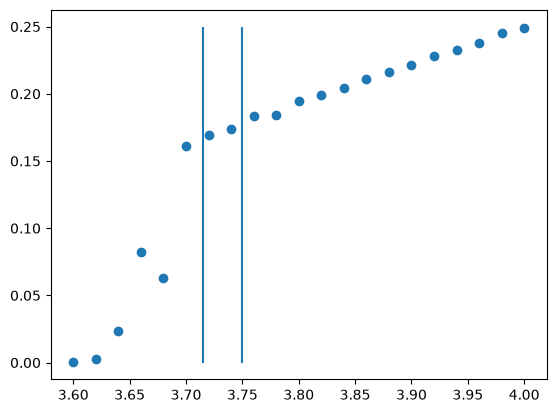

In [14]:
plt.scatter(np.arange(3.6, 4.02, 0.02), np.array(excitatory_firing_rates))
plt.vlines([3.715, 3.75], 0, 0.25)

In [36]:
high_excitatory_firing_rates = []
low_excitatory_firing_rates = []

for I in np.arange(3.6, 4.02, 0.02):
#for a in range(1):
    print("--------------")
    print(f"I = {I}")
    cell_params, synaptic_params, network_params = network_A(I, 1.4, 1.1, 0.01)
    
    #res = run_sim(cell_params, synaptic_params, network_params)
    #with gzip.open(f"pkls/fig7/SA-I-{I}.pkl.gzip", "wb") as f:
    #    pkl.dump(res, f)
    
    res = None
    with gzip.open(f"pkls/fig7/SA-I-{I}.pkl.gzip", "rb") as f:
        res = pkl.load(f)

    t, spikes, final_state = res

    activity = spikes.sum(axis=1)
    # use a rolling average to smooth out noise and find bursting windows
    bursting_filter = np.sum(np.lib.stride_tricks.sliding_window_view(activity, window_shape=101), axis=1) > 0
    # say somewhat arbitrarily that if we see activity windows after 50s that there exists a stable/metastable state
    # and that if there is a total period of >1s of silence after 50s that that means bursting
    if np.any(bursting_filter[50000:]) and np.sum(~bursting_filter[50000:]) >= 1000:
        print("Bursting")
        bursts = spikes[50:-50][bursting_filter,]
        excitatory_firing_rate = bursts[:,final_state.neuron_types].sum() / (bursts.shape[0] / 1000) / network_params.N / (1 - network_params.inhib_fraction)
        high_excitatory_firing_rates.append(excitatory_firing_rate)
        low_excitatory_firing_rates.append(0)
    else:
        excitatory_firing_rate = spikes[:,final_state.neuron_types].sum() / 100 / network_params.N / (1 - network_params.inhib_fraction)
        high_excitatory_firing_rates.append(excitatory_firing_rate)
        low_excitatory_firing_rates.append(None)
    print(excitatory_firing_rate)

--------------
I = 3.6
0.0007824999999999999
--------------
I = 3.62
0.0048575
--------------
I = 3.64
0.00266375
--------------
I = 3.66
0.0025350000000000004
--------------
I = 3.68
0.004017499999999999
--------------
I = 3.7
0.0036674999999999998
--------------
I = 3.72
0.00510375
--------------
I = 3.74
0.00465625
--------------
I = 3.7600000000000002
Bursting
0.15215280526419947
--------------
I = 3.7800000000000002
Bursting
0.15722085304646602
--------------
I = 3.8000000000000003
Bursting
0.1603715648673492
--------------
I = 3.8200000000000003
Bursting
0.17622509240190395
--------------
I = 3.8400000000000003
Bursting
0.1853061297389979
--------------
I = 3.8600000000000003
Bursting
0.18623766418991972
--------------
I = 3.8800000000000003
Bursting
0.19117793185682425
--------------
I = 3.9000000000000004
Bursting
0.19631099414959421
--------------
I = 3.9200000000000004
Bursting
0.2163503462426263
--------------
I = 3.9400000000000004
0.21846125
--------------
I = 3.9600000000

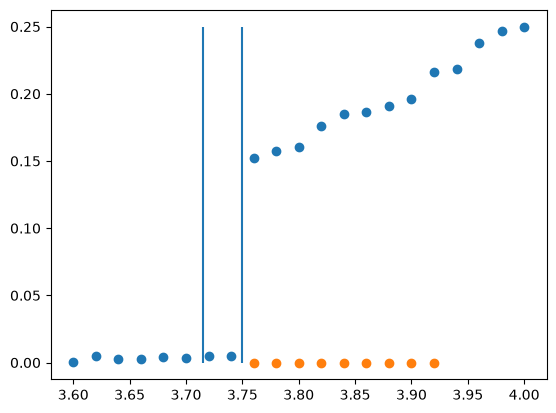

In [37]:
plt.scatter(np.arange(3.6, 4.02, 0.02), np.array(high_excitatory_firing_rates))
plt.scatter(np.arange(3.6, 4.02, 0.02), np.array(low_excitatory_firing_rates))
plt.vlines([3.715, 3.75], 0, 0.25)